=== ANÁLISE SHAP PARA ENTENDER RELAÇÃO COM STATUS NUTRICIONAL ===
Dataset shape: (3429, 39)

Features para análise: 36
Target distribution:
0    2580
1     849
Name: status_nutricional_who, dtype: int64
Target proportion: 0    0.752
1    0.248
Name: status_nutricional_who, dtype: float64

=== ANÁLISE DE DADOS FALTANTES ===
Features com dados faltantes:
Nenhuma feature com dados faltantes!

=== ANÁLISE EXPLORATÓRIA DAS 36 FEATURES ===
Variáveis numéricas: 30
  - h01_semanas_gravidez
  - h02_peso
  - h03_altura
  - k04_prenatal_semanas
  - k05_prenatal_consultas
  - k06_peso_engravidar
  - k07_peso_final
  - k08_quilos
  - imc_pre_gravidico
  - imc_final_gravidico
  - delta_imc
  - quilos_por_imc_pre
  - ganho_relativo
  - indice_ponderal
  - k12_tempo_horas
  - k18_somente_dias
  - velocidade_ganho_semanal
  - idade_materna_no_nascimento
  - delta_peso_absoluto_materno
  - delta_peso_relativo_materno
  - consultas_por_semana
  - cobertura_prenatal
  - def_idade_gest
  - adequacao_prenat

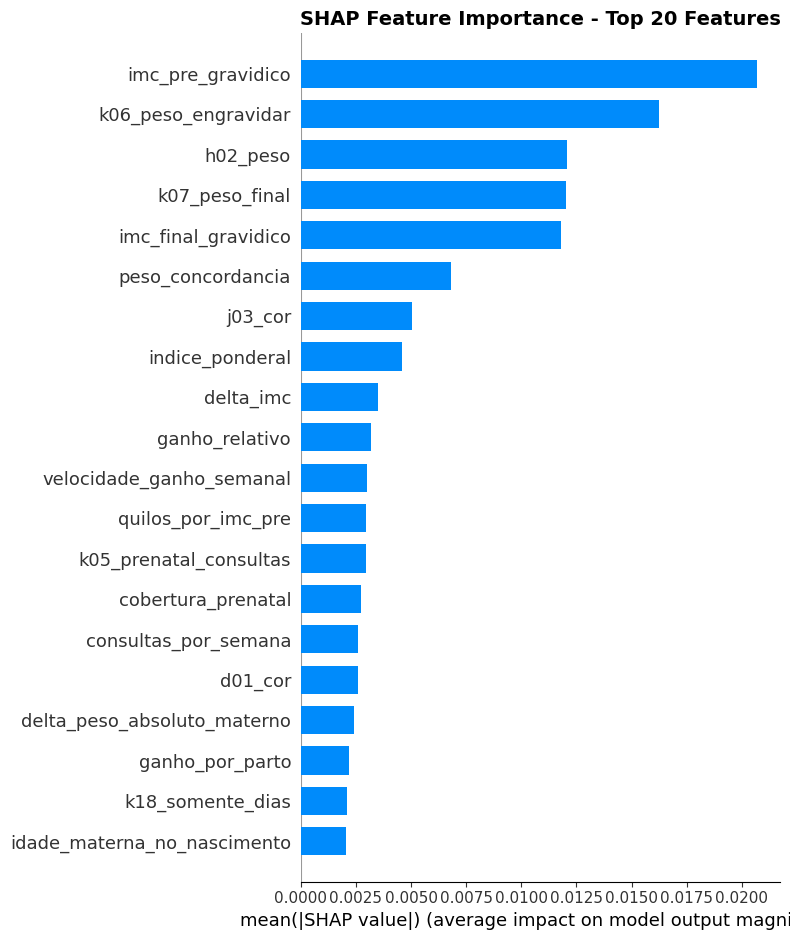

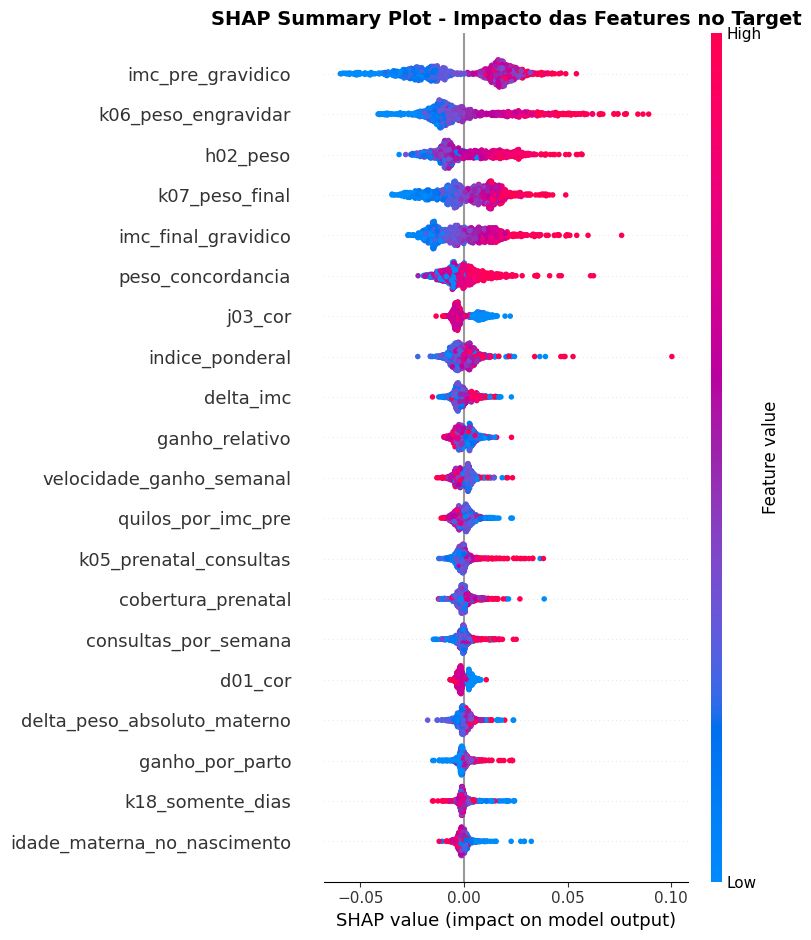

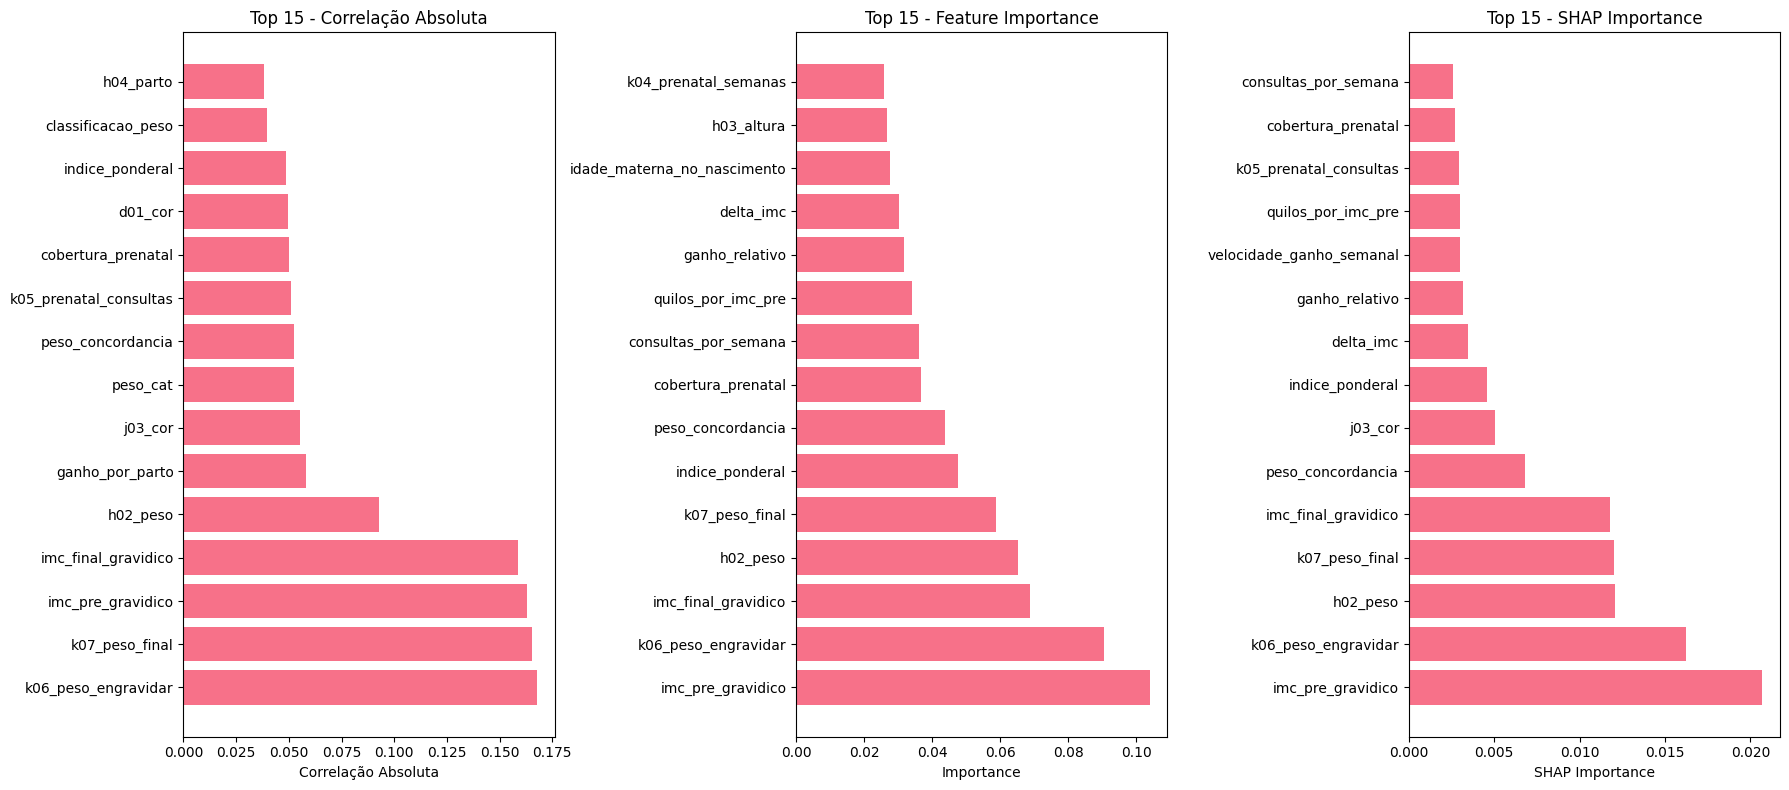


=== RANKING CONSOLIDADO DAS FEATURES ===
TOP 20 FEATURES MAIS IMPORTANTES (Ranking Consolidado):
Rank | Feature                   | Corr   | FI   | SHAP | Avg    | Correlation
------------------------------------------------------------------------------------------
5    | h02_peso                  | 5      | 4    | 4    | 4.3    | 0.093      
12   | d01_cor                   | 12     | 2    | 2    | 5.3    | -0.050     
1    | k06_peso_engravidar       | 1      | 10   | 10   | 7.0    | 0.168      
7    | j03_cor                   | 7      | 7    | 7    | 7.0    | -0.055     
2    | k07_peso_final            | 2      | 11   | 11   | 8.0    | 0.165      
17   | h03_altura                | 17     | 5    | 5    | 9.0    | 0.036      
15   | h04_parto                 | 15     | 6    | 6    | 9.0    | -0.038     
10   | k05_prenatal_consultas    | 10     | 9    | 9    | 9.3    | 0.051      
25   | h01_semanas_gravidez      | 25     | 3    | 3    | 10.3   | 0.022      
3    | imc_pre_gravid

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")

# Carregar dataset de treino
caminho_train = "/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/DatasetTrain.csv"
df_train = pd.read_csv(caminho_train)

print("=== ANÁLISE SHAP PARA ENTENDER RELAÇÃO COM STATUS NUTRICIONAL ===")
print(f"Dataset shape: {df_train.shape}")

# Definir variáveis a excluir
variaveis_excluir = ['id_anon', 'vd_zimc', 'status_nutricional_who']

# Separar features e target
y = df_train['status_nutricional_who'].copy()
X = df_train.drop(columns=variaveis_excluir).copy()

print(f"\nFeatures para análise: {len(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target proportion: {y.value_counts(normalize=True).round(3)}")

# Análise de dados faltantes
print("\n=== ANÁLISE DE DADOS FALTANTES ===")
missing_data = X.isnull().sum()
missing_percent = (missing_data / len(X) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

print("Features com dados faltantes:")
features_com_missing = missing_df[missing_df['Missing_Count'] > 0]
if len(features_com_missing) > 0:
    print(features_com_missing)
else:
    print("Nenhuma feature com dados faltantes!")

# Análise exploratória das features
print(f"\n=== ANÁLISE EXPLORATÓRIA DAS {len(X.columns)} FEATURES ===")

# Separar variáveis numéricas e categóricas
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Variáveis numéricas: {len(numeric_features)}")
for feat in numeric_features:
    print(f"  - {feat}")

print(f"\nVariáveis categóricas: {len(categorical_features)}")
for feat in categorical_features:
    unique_vals = X[feat].nunique()
    print(f"  - {feat}: {unique_vals} categorias únicas")

# Preprocessamento básico apenas para SHAP
print("\n=== PREPROCESSAMENTO PARA ANÁLISE SHAP ===")
X_processed = X.copy()
label_encoders = {}

# Encoding de variáveis categóricas
for col in categorical_features:
    print(f"Encoding {col}...")
    le = LabelEncoder()
    # Tratar valores faltantes primeiro
    X_processed[col] = X_processed[col].fillna('Missing')
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le

# Imputação simples para valores faltantes numéricos
if len(numeric_features) > 0:
    imputer = SimpleImputer(strategy='median')
    X_processed[numeric_features] = imputer.fit_transform(X_processed[numeric_features])

print(f"Shape após preprocessamento: {X_processed.shape}")
print(f"Dados faltantes restantes: {X_processed.isnull().sum().sum()}")

# Correlações simples com o target
print("\n=== CORRELAÇÕES COM O TARGET ===")
correlations = []
for col in X_processed.columns:
    corr = np.corrcoef(X_processed[col], y)[0,1]
    if not np.isnan(corr):
        correlations.append((col, corr, abs(corr)))

correlations_df = pd.DataFrame(correlations, columns=['feature', 'correlation', 'abs_correlation']).sort_values('abs_correlation', ascending=False)

print("TOP 15 CORRELAÇÕES (valor absoluto):")
print(correlations_df.head(15)[['feature', 'correlation']].round(3))

# Treinar modelo simples APENAS para análise SHAP
print("\n=== MODELO SIMPLES PARA ANÁLISE SHAP ===")
print("(Modelo usado apenas para gerar explicações SHAP, não para predição)")

# Modelo Random Forest simples
rf_simple = RandomForestClassifier(
    n_estimators=50,  # Menor para ser mais rápido
    max_depth=6,      # Mais simples
    random_state=42
)

rf_simple.fit(X_processed, y)
print("Modelo treinado com sucesso!")

# Feature importance básica
feature_importance = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': rf_simple.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTOP 15 FEATURES - Feature Importance:")
print(feature_importance.head(15)[['feature', 'importance']].round(4))

# ANÁLISE SHAP
print("\n=== GERANDO ANÁLISE SHAP ===")
print("Criando explainer SHAP...")

# Usar uma amostra menor para SHAP (mais rápido)
sample_size = min(1000, len(X_processed))
sample_indices = np.random.choice(len(X_processed), size=sample_size, replace=False)
X_sample = X_processed.iloc[sample_indices]

explainer = shap.TreeExplainer(rf_simple)
shap_values = explainer.shap_values(X_sample)

# Se for classificação binária, pegar a classe 1
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_analysis = shap_values[1]
else:
    shap_values_analysis = shap_values

print(f"SHAP values calculados para {sample_size} amostras!")

# Importância SHAP
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'shap_importance': np.abs(shap_values_analysis).mean(0)
}).sort_values('shap_importance', ascending=False)

print("\nTOP 15 FEATURES - SHAP Importance:")
print(shap_importance.head(15)[['feature', 'shap_importance']].round(4))

# Visualizações SHAP
print("\n=== CRIANDO VISUALIZAÇÕES SHAP ===")

# 1. SHAP Summary Plot (barras)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_analysis, X_sample, plot_type="bar", show=False, max_display=20)
plt.title('SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/shap_importance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# 2. SHAP Summary Plot (detalhado)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_analysis, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot - Impacto das Features no Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/shap_summary.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# 3. Comparação dos rankings
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Correlação
top_15_corr = correlations_df.head(15)
axes[0].barh(range(len(top_15_corr)), top_15_corr['abs_correlation'])
axes[0].set_yticks(range(len(top_15_corr)))
axes[0].set_yticklabels(top_15_corr['feature'])
axes[0].set_title('Top 15 - Correlação Absoluta')
axes[0].set_xlabel('Correlação Absoluta')

# Feature Importance
top_15_fi = feature_importance.head(15)
axes[1].barh(range(len(top_15_fi)), top_15_fi['importance'])
axes[1].set_yticks(range(len(top_15_fi)))
axes[1].set_yticklabels(top_15_fi['feature'])
axes[1].set_title('Top 15 - Feature Importance')
axes[1].set_xlabel('Importance')

# SHAP Importance
top_15_shap = shap_importance.head(15)
axes[2].barh(range(len(top_15_shap)), top_15_shap['shap_importance'])
axes[2].set_yticks(range(len(top_15_shap)))
axes[2].set_yticklabels(top_15_shap['feature'])
axes[2].set_title('Top 15 - SHAP Importance')
axes[2].set_xlabel('SHAP Importance')

plt.tight_layout()
plt.savefig('/Users/marcelosilva/Desktop/projectOne/6/B- Binary Target DS DT/comparison_rankings.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Consolidar rankings
print("\n=== RANKING CONSOLIDADO DAS FEATURES ===")

# Criar ranking consolidado
ranking_consolidado = []
for i, row in correlations_df.iterrows():
    feature = row['feature']
    
    # Posição no ranking de correlação
    corr_rank = correlations_df.index.get_loc(i) + 1
    
    # Posição no ranking de feature importance
    fi_rank = feature_importance[feature_importance['feature'] == feature].index[0] + 1
    
    # Posição no ranking SHAP
    shap_rank = shap_importance[shap_importance['feature'] == feature].index[0] + 1
    
    # Ranking médio
    avg_rank = (corr_rank + fi_rank + shap_rank) / 3
    
    ranking_consolidado.append({
        'feature': feature,
        'corr_rank': corr_rank,
        'fi_rank': fi_rank,
        'shap_rank': shap_rank,
        'avg_rank': avg_rank,
        'correlation': row['correlation']
    })

ranking_df = pd.DataFrame(ranking_consolidado).sort_values('avg_rank')

print("TOP 20 FEATURES MAIS IMPORTANTES (Ranking Consolidado):")
print("=" * 90)
print(f"{'Rank':<4} | {'Feature':<25} | {'Corr':<6} | {'FI':<4} | {'SHAP':<4} | {'Avg':<6} | {'Correlation':<11}")
print("-" * 90)

for idx, row in ranking_df.head(20).iterrows():
    print(f"{idx+1:<4} | {row['feature']:<25} | {row['corr_rank']:<6.0f} | {row['fi_rank']:<4.0f} | {row['shap_rank']:<4.0f} | {row['avg_rank']:<6.1f} | {row['correlation']:<11.3f}")

# Salvar resultados
ranking_df.to_csv('/Users/marcelosilva/Desktop/projectOne/6/C-SHAP Play/features_analysis_ranking.csv', index=False)
correlations_df.to_csv('/Users/marcelosilva/Desktop/projectOne/6/C-SHAP Play/features_correlations.csv', index=False)
feature_importance.to_csv('/Users/marcelosilva/Desktop/projectOne/6/C-SHAP Play/features_importance.csv', index=False)
shap_importance.to_csv('/Users/marcelosilva/Desktop/projectOne/6/C-SHAP Play/features_shap_importance.csv', index=False)

print(f"\n=== ARQUIVOS SALVOS ===")
print("✅ features_analysis_ranking.csv - Ranking consolidado")
print("✅ features_correlations.csv - Correlações com target") 
print("✅ features_importance.csv - Feature importance")
print("✅ features_shap_importance.csv - SHAP importance")
print("✅ shap_importance.png - Gráfico SHAP importance")
print("✅ shap_summary.png - SHAP summary plot")
print("✅ comparison_rankings.png - Comparação dos rankings")

print(f"\n=== CONCLUSÃO DA ANÁLISE ===")
print(f"✅ Analisadas {len(X.columns)} features")
print(f"✅ Identificadas as top 20 features mais relacionadas ao status nutricional")
print(f"✅ Pronto para próxima etapa: feature selection ou PyCaret")